In [15]:
import re

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from loan_approval.config import DATA_RAW_DIR, DATA_PROCESSED_DIR, FIGURES_DIR
import seaborn as sns

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', lambda x: '%.0f' % x)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def slugify(text):
    return re.sub(r"[^a-zA-Z0-9]+", "_", text).strip("_").lower()

# LAR Field Reference

| Field | Description |
|---|---|
| lei | Financial institution's Legal Entity Identifier |
| action_taken | Outcome of the loan application (originated, denied, withdrawn, etc.) |
| debt_to_income_ratio | Applicant's total monthly debt as % of monthly income |
| loan_to_value_ratio | Total debt secured by property vs. property value |
| applicant_credit_score_type | Credit scoring model used for applicant |
| co-applicant_credit_score_type | Credit scoring model used for co-applicant |
| income | Gross annual income relied on in credit decision (in thousands) |
| property_value | Value of property securing the loan |
| loan_amount | Amount of the loan or amount applied for |
| loan_type | Conventional, FHA, VA, or RHS/FSA loan |
| occupancy_type | Principal residence, second residence, or investment property |
| denial_reason-1 to -4 | Principal reason(s) for denial (up to 4) |
| loan_term | Loan maturity term in months |
| interest_only_payment | Whether loan includes interest-only payments |
| negative_amortization | Whether loan terms allow negative amortization |
| balloon_payment | Whether loan includes a balloon payment |
| aus-1 to aus-5 | Automated underwriting system(s) used (up to 5) |
| rate_spread | Difference between loan APR and average prime offer rate (APOR) |
| hoepa_status | Whether loan is classified as high-cost (HOEPA) |

In [16]:
cols = ['lei','action_taken','debt_to_income_ratio','loan_to_value_ratio',
    'applicant_credit_score_type','co-applicant_credit_score_type',
    'income','property_value','loan_amount','loan_purpose','loan_type','occupancy_type',
    'denial_reason-1','denial_reason-2','denial_reason-3','denial_reason-4',
    'loan_term','interest_only_payment','negative_amortization','balloon_payment',
    'aus-1','aus-2','aus-3','aus-4','rate_spread','hoepa_status']
BANK_LEIS = {
    "Truist Bank": "JJKC32MCHWDI71265Z06",
    "Wells Fargo Bank, N.A.": "KB1H1DSPRFMYMCUFXT09",
    "Bank of America, N.A.": "B4TYDEB6GKMZO031MB27",
}
df = pd.read_csv(DATA_RAW_DIR / 'hmda_data.csv', usecols=cols, low_memory=False)

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 468095 entries, 0 to 468094
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   lei                             468095 non-null  str    
 1   action_taken                    468095 non-null  int64  
 2   loan_type                       468095 non-null  int64  
 3   loan_purpose                    468095 non-null  int64  
 4   loan_amount                     468095 non-null  float64
 5   loan_to_value_ratio             297614 non-null  float64
 6   rate_spread                     215840 non-null  float64
 7   hoepa_status                    468095 non-null  int64  
 8   loan_term                       466432 non-null  float64
 9   negative_amortization           468095 non-null  int64  
 10  interest_only_payment           468095 non-null  int64  
 11  balloon_payment                 468095 non-null  int64  
 12  property_value             

In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
action_taken,468095,3,2,1,1,3,4,8
loan_type,468095,1,1,1,1,1,1,4
loan_purpose,468095,12,14,1,1,4,31,32
loan_amount,468095,233852,1310858,5000,85000,165000,275000,460305000
loan_to_value_ratio,297614,70,259,0,55,73,80,84743
rate_spread,215840,0,1,-8,-0,0,1,8
hoepa_status,468095,2,0,2,2,2,3,3
loan_term,466432,328,65,1,360,360,360,481
negative_amortization,468095,2,0,1,2,2,2,2
interest_only_payment,468095,2,0,1,2,2,2,2


In [19]:
approved = [1,2,8]
denied = [3,7]
model_df = df[df['action_taken'].isin(approved + denied)]
model_df['approved'] = model_df['action_taken'].isin(approved).astype(int)

In [20]:
# If the target is imbalanced
rate = model_df['approved'].mean()
print(f"Target has: {rate:.1%} approved rate")

Target has: 70.4% approved rate


### Plot shows approved/denied per bank

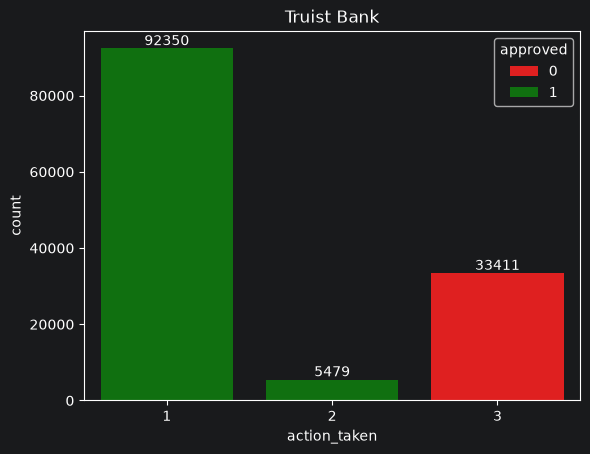

Truist Bank: 74.5% approved


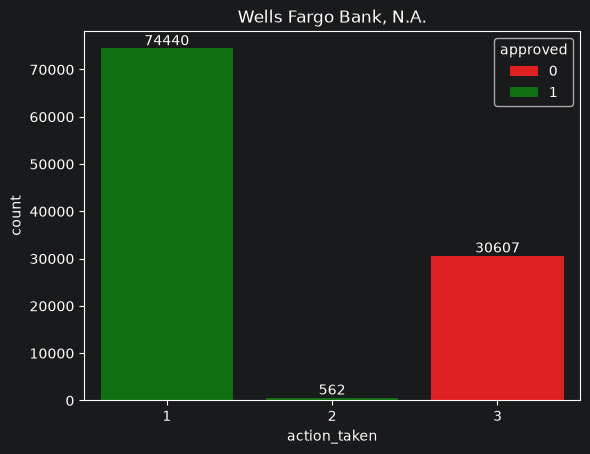

Wells Fargo Bank, N.A.: 71.0% approved


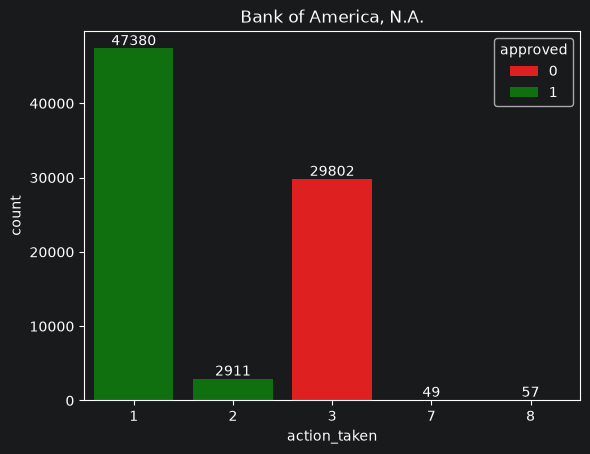

Bank of America, N.A.: 62.8% approved


In [21]:
for bank, lei in BANK_LEIS.items():
      bank_df = model_df[model_df["lei"] == lei]
      ax = sns.countplot(
          data=bank_df,
          x="action_taken",
          hue="approved",
          palette={1: "green", 0: "red"},
      )
      for container in ax.containers:
          ax.bar_label(container)
      plt.title(bank)
      plt.savefig(FIGURES_DIR / f"action_taken__{slugify(bank)}.png", bbox_inches="tight")
      plt.show()

      approved_rate = bank_df["approved"].mean()
      print(f"{bank}: {approved_rate:.1%} approved")

### Plot shows loan type that got approved the most

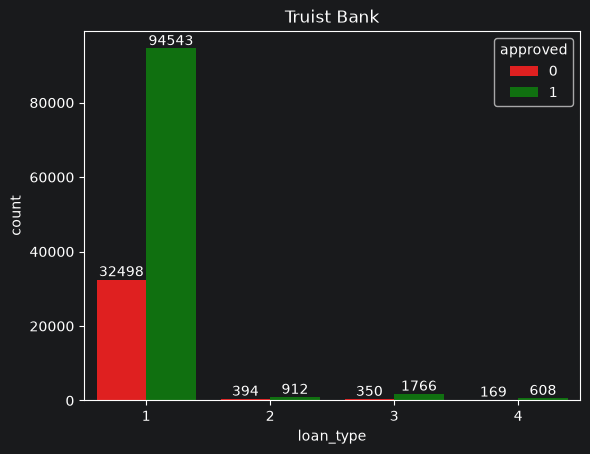

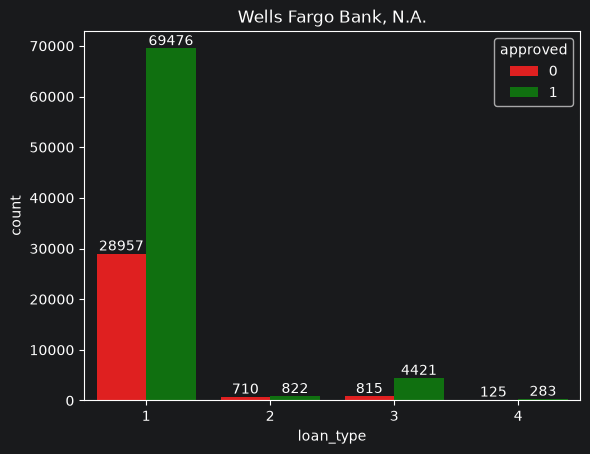

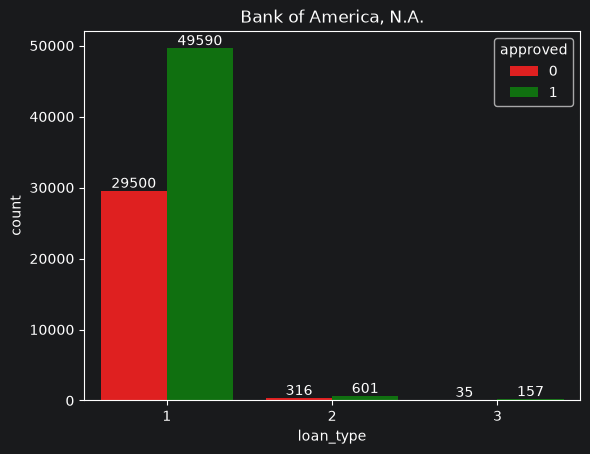

In [22]:
for bank, lei in BANK_LEIS.items():
      bank_df = model_df[model_df["lei"] == lei]
      ax = sns.countplot(
          data=bank_df,
          x="loan_type",
          hue="approved",
          palette={1: "green", 0: "red"},
      )
      for container in ax.containers:
          ax.bar_label(container)
      plt.title(bank)
      plt.savefig(FIGURES_DIR / f"loan_type__{slugify(bank)}.png", bbox_inches="tight")
      plt.show()

### Loan term that got approved

In [23]:
term_stats = (
    model_df
    .groupby(['lei', 'approved'])['loan_term']
    .agg(['mean', 'median'])
    .reset_index()
  )
term_stats['bank'] = term_stats['lei'].map({v: k for k, v in BANK_LEIS.items()})
term_stats

,lei,approved,mean,median,bank
0,B4TYDEB6GKMZO031MB27,0,356,360,"Bank of America, N.A."
1,B4TYDEB6GKMZO031MB27,1,334,360,"Bank of America, N.A."
2,JJKC32MCHWDI71265Z06,0,325,360,Truist Bank
3,JJKC32MCHWDI71265Z06,1,317,360,Truist Bank
4,KB1H1DSPRFMYMCUFXT09,0,325,360,"Wells Fargo Bank, N.A."
5,KB1H1DSPRFMYMCUFXT09,1,316,360,"Wells Fargo Bank, N.A."


### Loan purpose vs approved

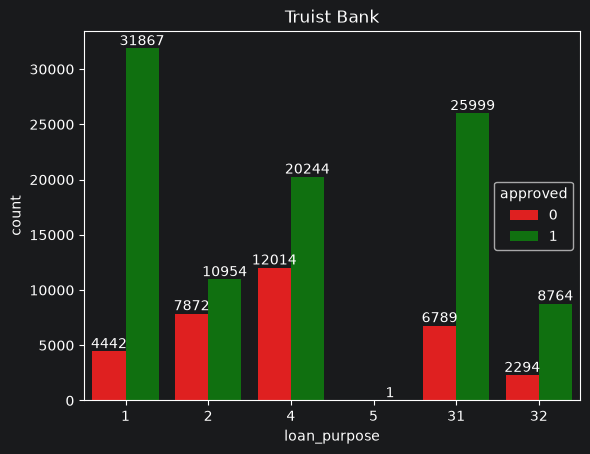

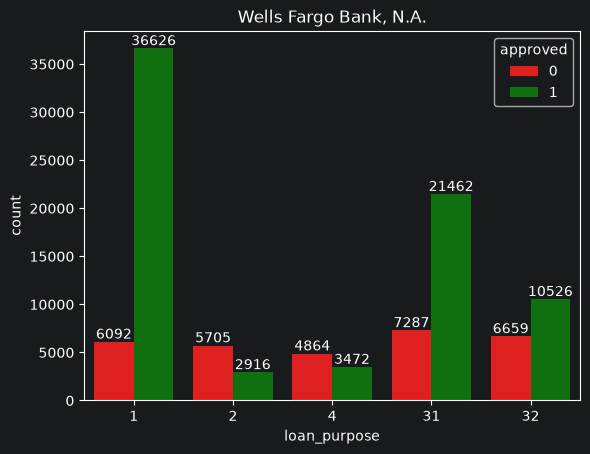

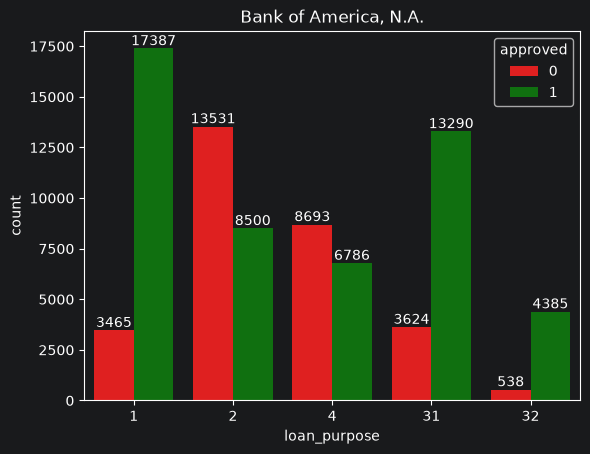

In [24]:
for bank, lei in BANK_LEIS.items():
      bank_df = model_df[model_df["lei"] == lei]
      ax = sns.countplot(
          data=bank_df,
          x="loan_purpose",
          hue="approved",
          palette={1: "green", 0: "red"},
      )
      for container in ax.containers:
          ax.bar_label(container)
      plt.title(bank)
      plt.savefig(FIGURES_DIR / f"loan_purpose__{slugify(bank)}.png", bbox_inches="tight")
      plt.show()

### Everything else

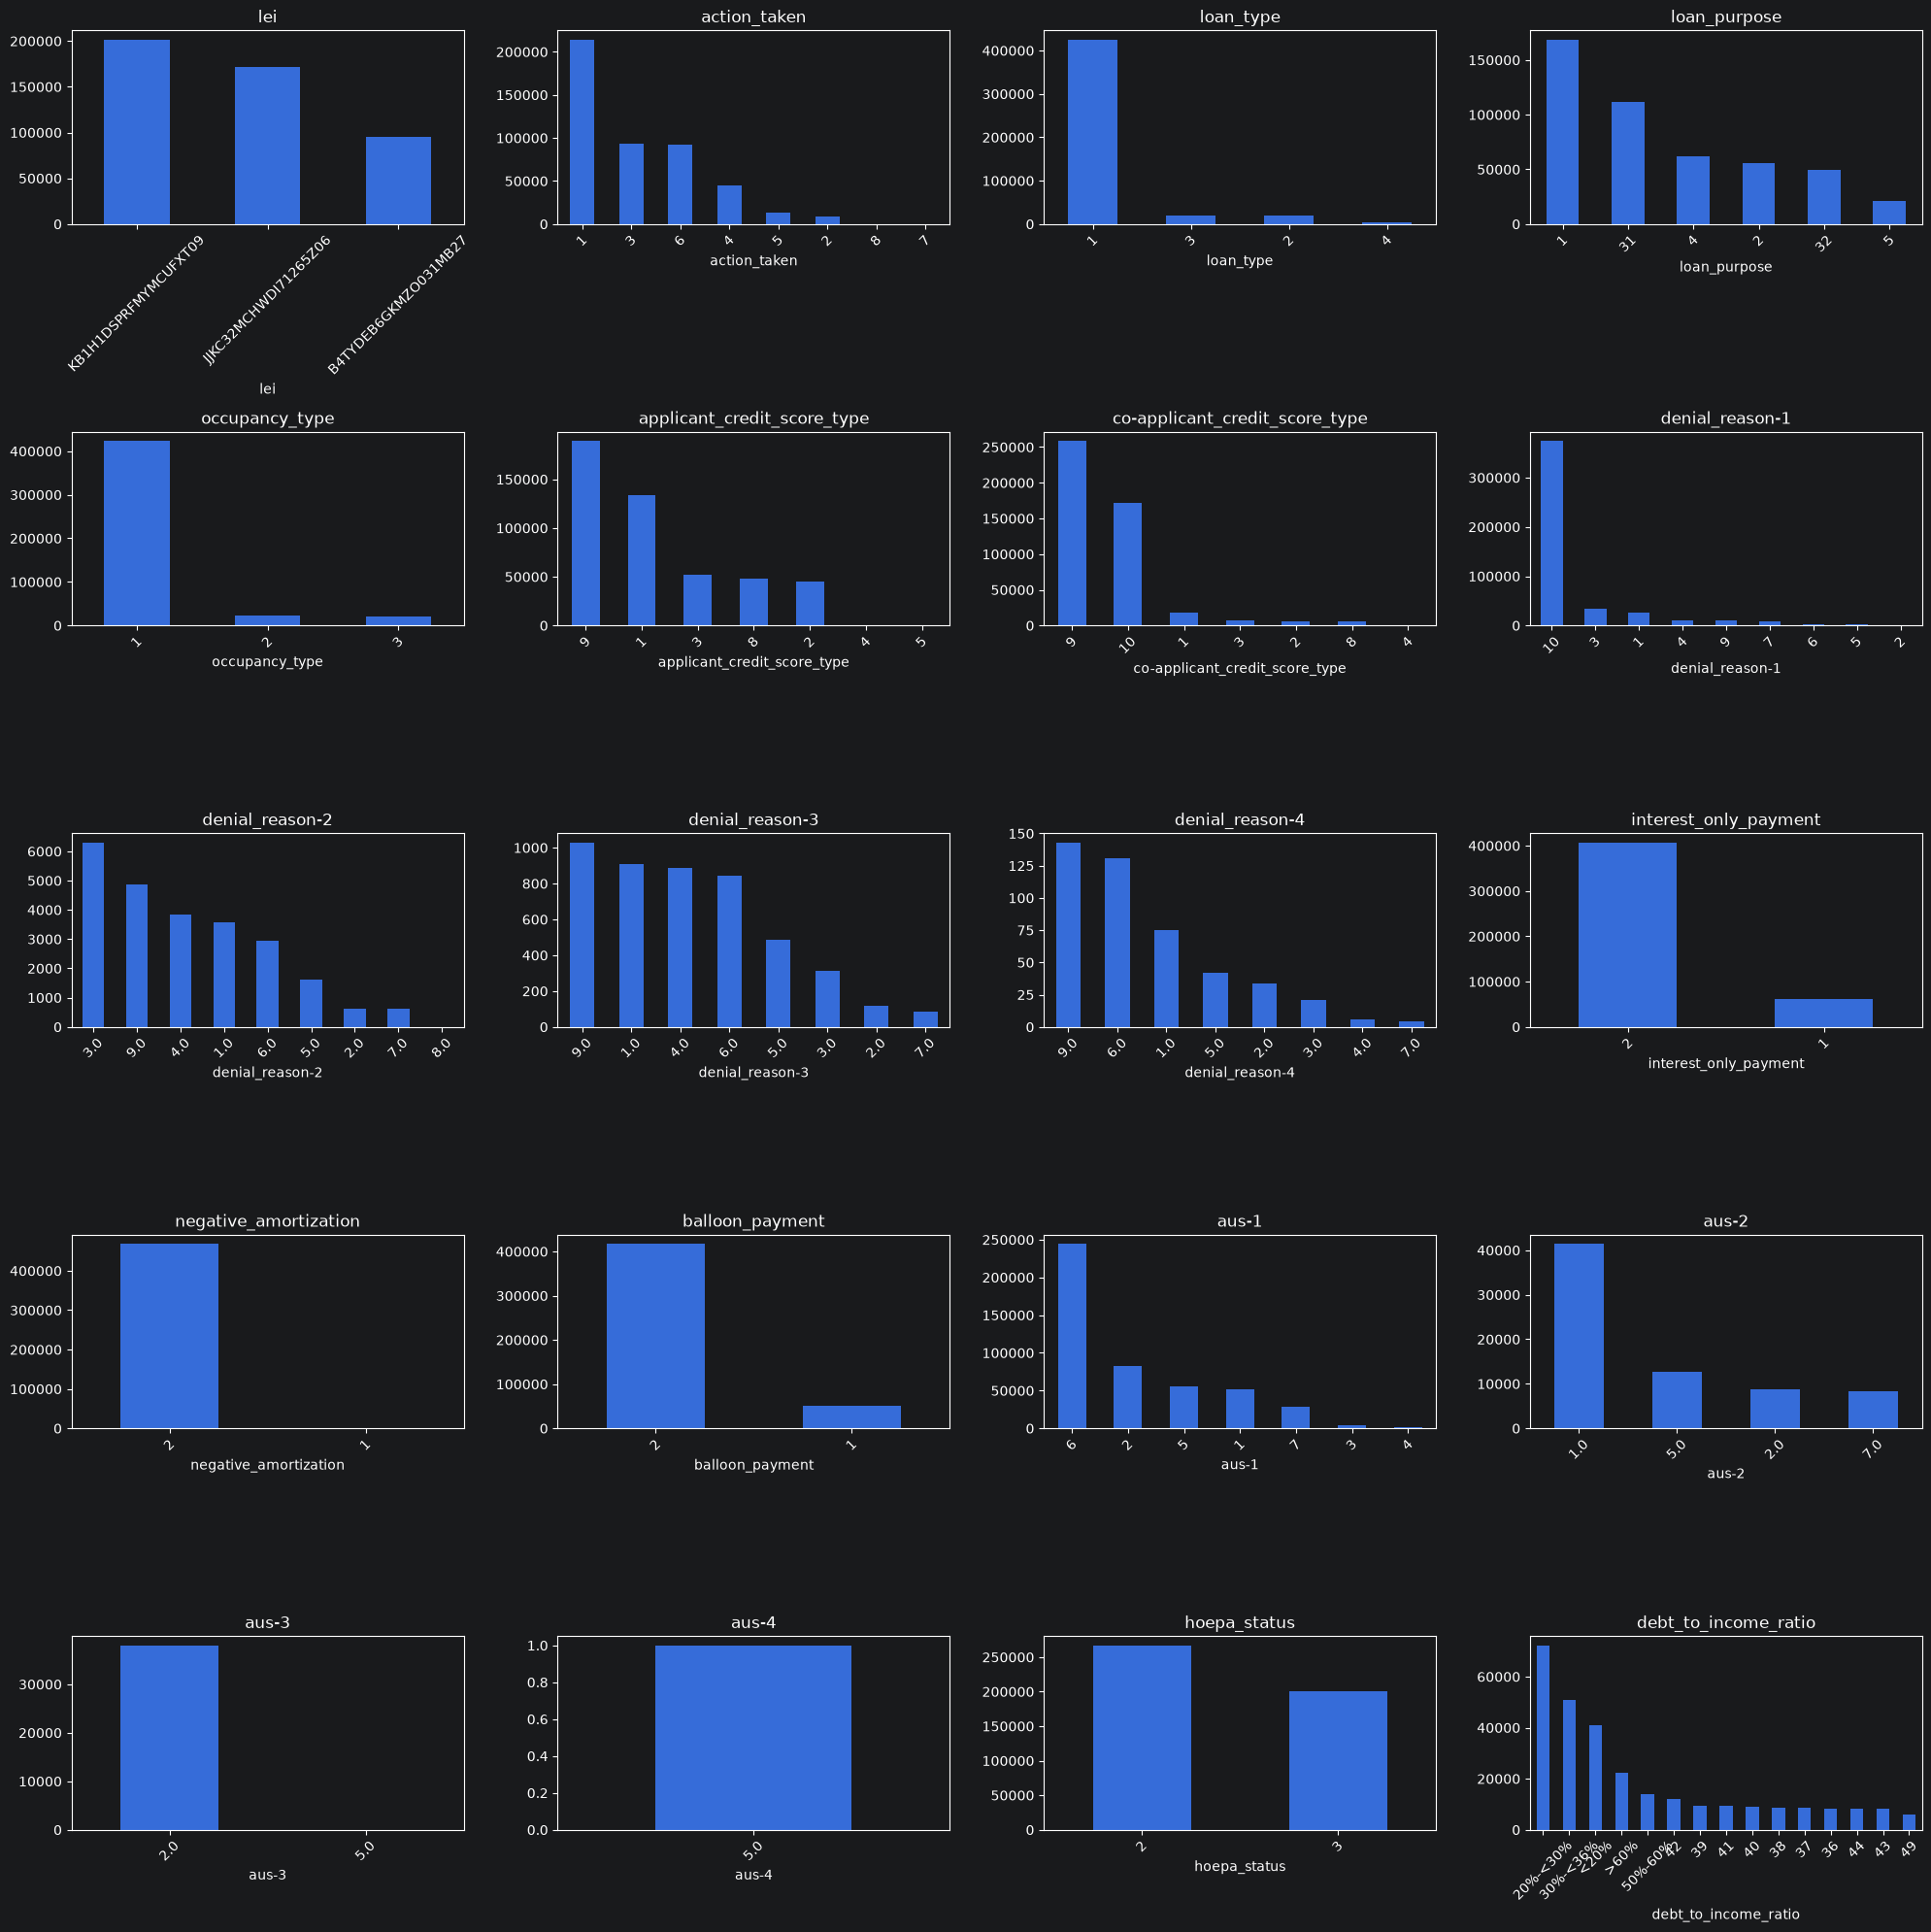

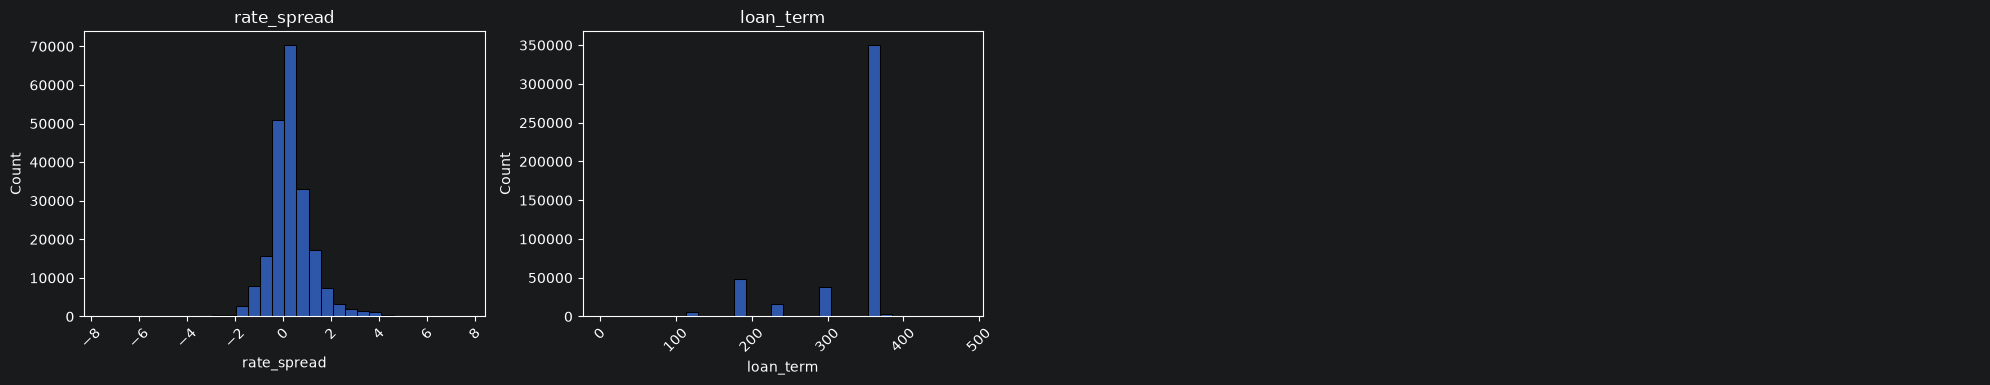

In [25]:
# FLAG
import math

categorical_cols = [
    "lei", "action_taken", "loan_type", "loan_purpose", "occupancy_type",
    "applicant_credit_score_type", "co-applicant_credit_score_type",
    "denial_reason-1", "denial_reason-2", "denial_reason-3", "denial_reason-4",
    "interest_only_payment", "negative_amortization", "balloon_payment",
    "aus-1", "aus-2", "aus-3", "aus-4", "hoepa_status",
    "debt_to_income_ratio",
]
outlier_cols = ["loan_amount", "loan_to_value_ratio", "property_value", "income"]
numeric_cols = [c for c in df.columns if c not in categorical_cols and c not in outlier_cols]

def plot_grid(cols_to_plot, kind, n_cols=4, filename=None):
    n_rows = math.ceil(len(cols_to_plot) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for ax, col in zip(axes, cols_to_plot):
        data = df[col].dropna()
        if data.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center")
            ax.set_title(col)
            continue

        if kind == "categorical":
            data.value_counts().head(15).plot(kind="bar", ax=ax)
        else:
            sns.histplot(data, ax=ax, bins=30)
        ax.set_title(col)
        ax.tick_params(axis="x", labelrotation=45)

    for ax in axes[len(cols_to_plot):]:
        ax.axis("off")

    plt.tight_layout()
    if filename:
        plt.savefig(FIGURES_DIR / filename, bbox_inches="tight")
    plt.show()

plot_grid(categorical_cols, kind="categorical", filename="overview__categorical.png")
plot_grid(numeric_cols, kind="numeric", filename="overview__numeric.png")

<Axes: >

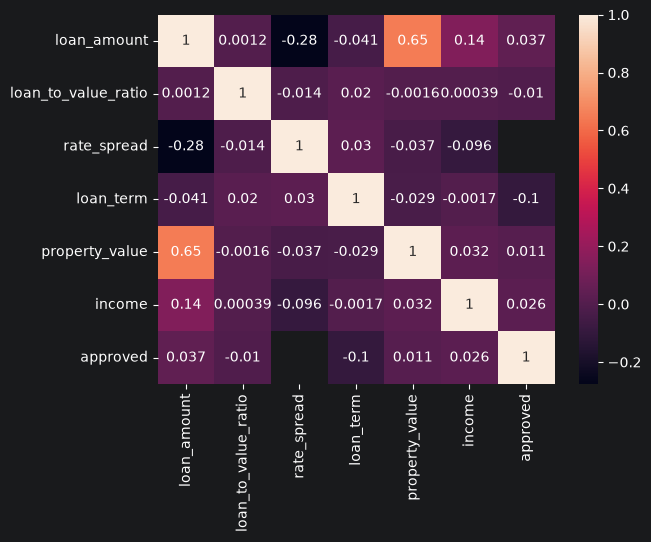

In [37]:
sns.heatmap(model_df.drop(columns=["lei",'debt_to_income_ratio',*categorical_cols]).corr(), annot=True)

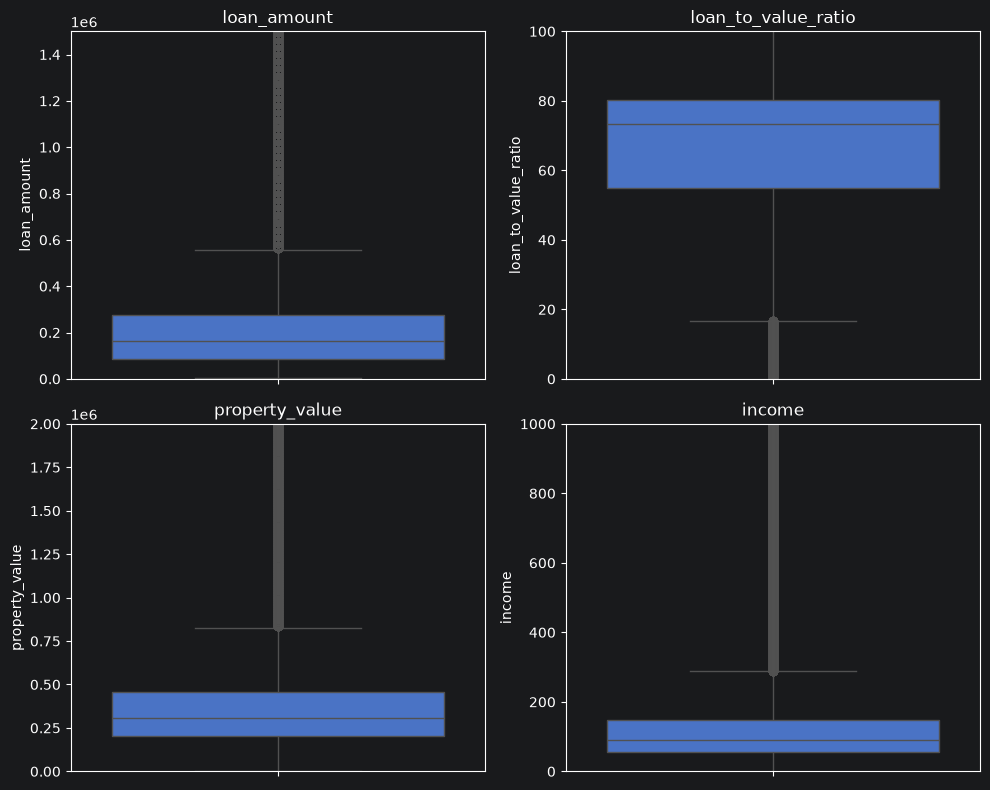

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

ylims = {
    "loan_to_value_ratio": (0, 100),
    "income": (0, 1_000),
    "loan_amount": (0, 1_500_000),
    "property_value": (0, 2_000_000),
}

for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df[col].dropna(), ax=ax)
    if col in ylims:
        ax.set_ylim(*ylims[col])
    else:
        ax.set_yscale("symlog")
    ax.set_title(col)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "outlier_boxplots.png", bbox_inches="tight")
plt.show()

### Five-number summary (0-25-50-75-100) for all numeric columns

Apply the standard Tukey rule to every numeric column (`outlier_cols` +
`numeric_cols`): take the p0/p25/p50/p75/p100 quantiles, then flag anything
outside `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]` as an outlier.

In [31]:
all_numeric_cols = outlier_cols + numeric_cols

five_num = df[all_numeric_cols].quantile([0, .25, .5, .75, 1]).T
five_num.columns = ["p0_min", "p25", "p50_median", "p75", "p100_max"]

five_num["IQR"] = five_num["p75"] - five_num["p25"]
five_num["lower_bound"] = five_num["p25"] - 1.5 * five_num["IQR"]
five_num["upper_bound"] = five_num["p75"] + 1.5 * five_num["IQR"]

for col in all_numeric_cols:
    data = df[col]
    lb, ub = five_num.loc[col, ["lower_bound", "upper_bound"]]
    n_outliers = ((data < lb) | (data > ub)).sum()
    five_num.loc[col, "n_outliers"] = n_outliers
    five_num.loc[col, "pct_outliers"] = n_outliers / data.notna().sum()

five_num

,p0_min,p25,p50_median,p75,p100_max,IQR,lower_bound,upper_bound,n_outliers,pct_outliers
loan_amount,5000,85000,165000,275000,460305000,190000,-200000,560000,20594,0
loan_to_value_ratio,0,55,73,80,84743,26,17,119,7278,0
property_value,5000,205000,305000,455000,2147483647,250000,-170000,830000,24378,0
income,-12252,56,91,149,500034,93,-84,288,28369,0
rate_spread,-8,-0,0,1,8,1,-1,2,15057,0
loan_term,1,360,360,360,481,0,360,360,135910,0


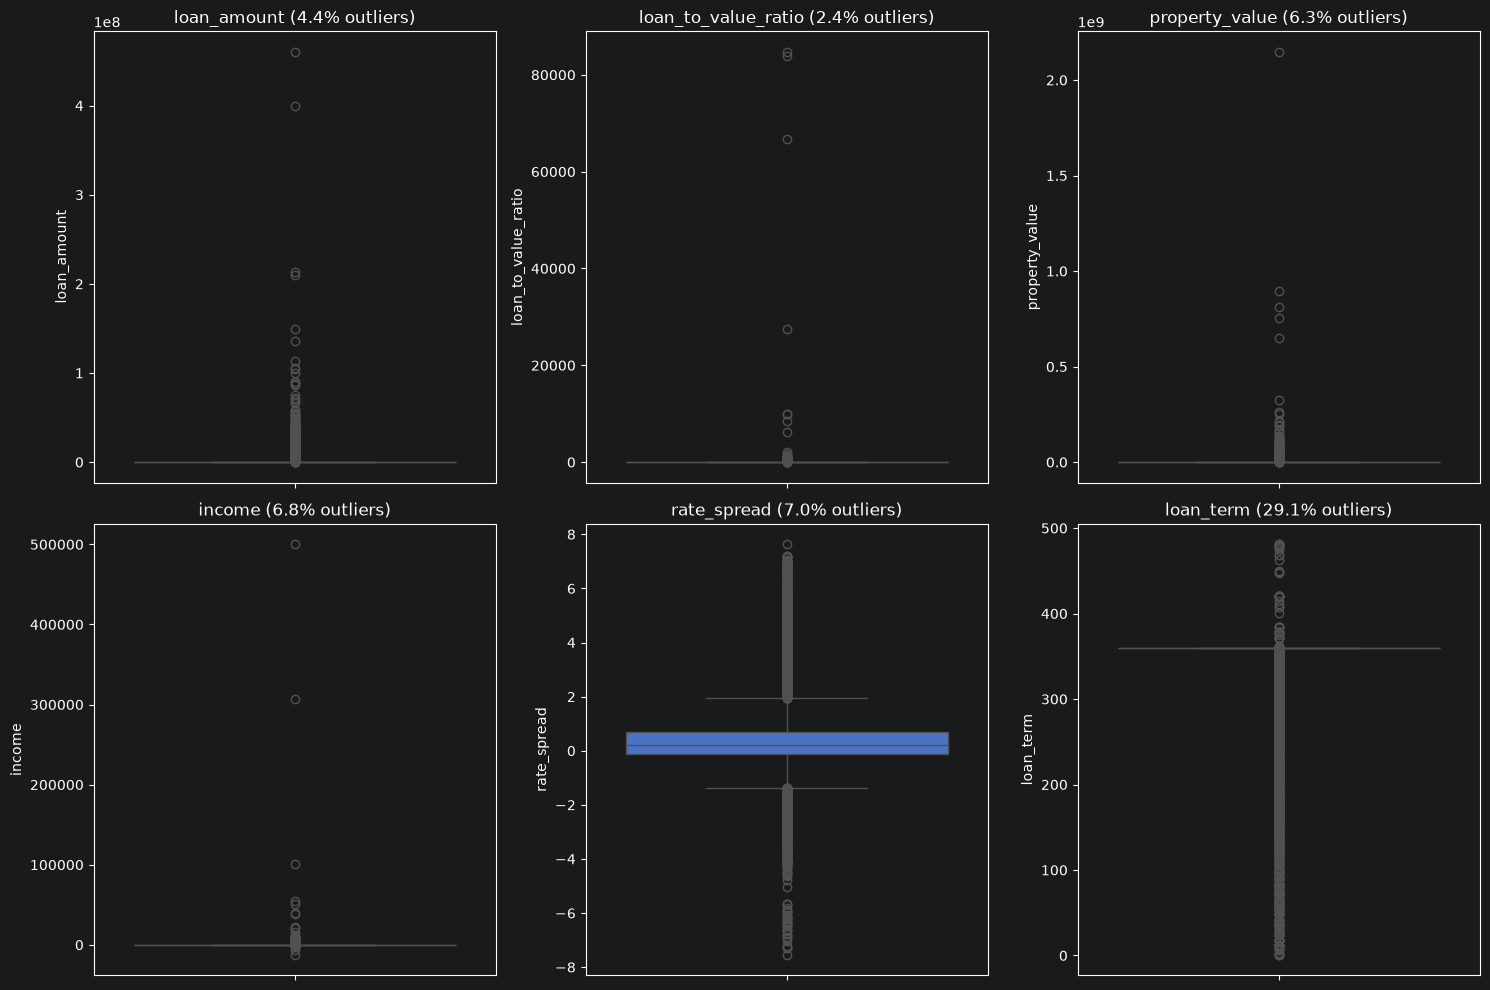

In [32]:
n_cols = 3
n_rows = math.ceil(len(all_numeric_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, all_numeric_cols):
    sns.boxplot(y=df[col].dropna(), ax=ax)
    ax.set_title(f"{col} ({five_num.loc[col, 'pct_outliers']:.1%} outliers)")

for ax in axes[len(all_numeric_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "numeric_cols_boxplots.png", bbox_inches="tight")
plt.show()

### KEY insight

- **Approval rate varies meaningfully by bank.**
    - Truist            74.5%
    - Wells Fargo       71.0%
    - Bank of America   62.8% —
    > ~12-point gap between the highest and lowest bank, despite all three lending mostly conventional loans.

- **Loan type is overwhelmingly conventional at every bank** (92.6%–98.5% of approvals), but the mix of government-backed loans differs: Wells Fargo has the most diversified book, with VA loans making up ~5.9% of its approvals vs. 1.8% at Truist and just 0.3% at Bank of America.

- **Loan term is not a major driver of approve/deny outcomes.** The 360-month (30-year) term dominates both approved and denied applications at every bank, and mean loan term only differs modestly between the two groups (8 months at Truist/Wells Fargo, ~22 months at Bank of America) — approval decisions are being driven by other factors, not term length itself.

- **Loan purpose is a much stronger signal than loan type or term.** Approval rate drops sharply by purpose: home purchase (86.0%) and refinancing (77.4%) approve far more often than home improvement loans (45.2%) or "other purpose" loans (54.4%) across the whole portfolio. This pattern holds at every bank individually, making `loan_purpose` a strong candidate predictor for the approval model.

- **Bank-level differences compound with purpose.** Home-improvement approval rate ranges from 33.8% (Wells Fargo) to 58.2% (Truist) — nearly a 2x spread for the same loan purpose — suggesting bank identity (`lei`) itself carries real signal beyond just differing purpose/type mixes, and should be kept as a feature (or the model should be trained/evaluated per bank) rather than pooling all banks as if they underwrite identically.

In [29]:
model_df.to_csv(DATA_PROCESSED_DIR / 'hmda_data_processed.csv')